In [6]:
# Import libraries and utilities
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Import our reusable model utilities
from model_utils import (
    load_data, prepare_data, train_all_models, 
    plot_performance_comparison, plot_confusion_matrices,
    print_class_distribution, results_to_dataframe, save_models
)

In [ ]:
# Load data (UNBALANCED / natural distribution)
features_path = "../../data/ale_simplicistic_model/relative/featured/features_unbalanced.parquet"
target_path = "../../data/ale_simplicistic_model/relative/featured/target_unbalanced.parquet"

X, y_loaded, feature_cols = load_data(features_path, target_path)
print(f"Features shape: {X.shape}")


✓ Features and targets aligned by did_id: 100000 samples
Features shape: (100000, 22)


## Single-Output Week 2 Prediction Strategy

We'll train **single-output models** that predict block activity class for week 2 from week 1 features:
- 0 blocks -> class 0 (Inactive)
- 1–3 blocks -> class 1 (Low activity)
- 4+ blocks -> class 2 (High activity)

**Key approach:**
- Single model takes week 1 features as input
- Outputs 1 prediction: week2_class
- Uses standard sklearn classifiers

**Goals:**
1. Predict user behavior for the next week (week 2)
2. Compare different models: Logistic Regression, Random Forest, Gradient Boosting
3. Visualize confusion matrices and performance metrics

This helps us understand immediate next-week behavioral patterns.

In [8]:
# Extract Week 2 target and show distribution
y = y_loaded['blocks_week2_class'].astype(int)
print_class_distribution(y, "Week 2")


Week 2 class distribution:
  Class 0: 48,356 samples (48.4%)
  Class 1: 25,358 samples (25.4%)
  Class 2: 26,286 samples (26.3%)


In [ ]:
# Prepare data for Week 2 models
data = prepare_data(X, y, test_size=0.6)
print_class_distribution(data['y_train'], "Train set")
print_class_distribution(data['y_test'], "Test set")

Train/Test split: (50000, 22) / (50000, 22)

Train set class distribution:
  Class 0: 24,178 samples (48.4%)
  Class 1: 12,679 samples (25.4%)
  Class 2: 13,143 samples (26.3%)

Test set class distribution:
  Class 0: 24,178 samples (48.4%)
  Class 1: 12,679 samples (25.4%)
  Class 2: 13,143 samples (26.3%)


### Train Models for Week 2 Prediction

We'll train three types of models to predict week 2 activity class.

In [11]:
# Train all models for Week 2 in one call
results_week2 = train_all_models(data, week_label="Week 2")

TRAINING ALL MODELS - Week 2



LogisticRegression (Week 2):
  Accuracy: 0.5652
  Macro F1: 0.5387
  Weighted F1: 0.5699

RandomForest (Week 2):
  Accuracy: 0.5949
  Macro F1: 0.5347
  Weighted F1: 0.5775

GradientBoosting (Week 2):
  Accuracy: 0.6121
  Macro F1: 0.5098
  Weighted F1: 0.5630

✓ All models trained


### Model Performance Comparison

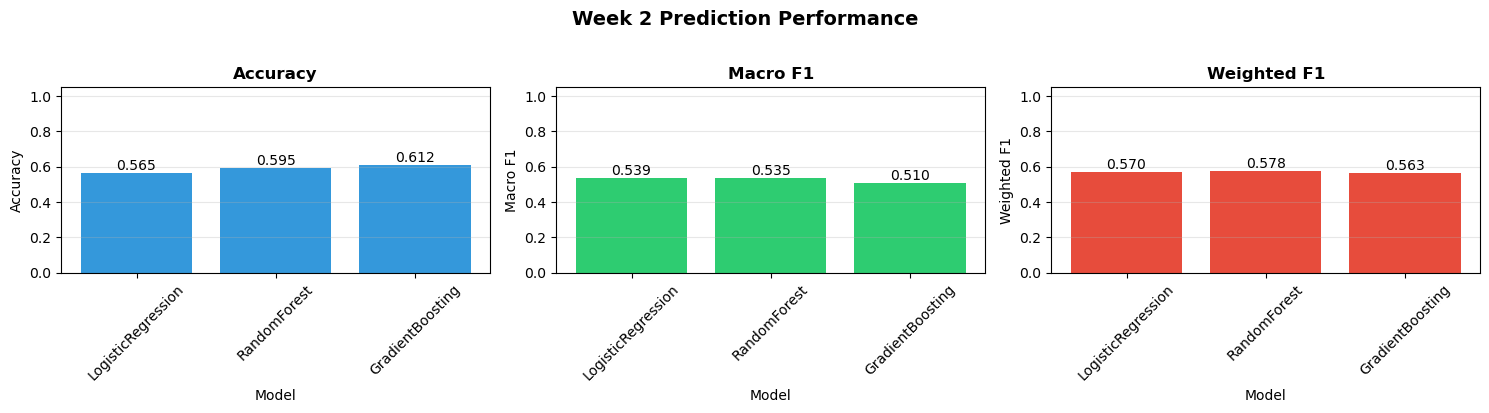


🏆 Best model (by Macro F1): LogisticRegression = 0.5387

             Model  Accuracy  Macro F1  Weighted F1
LogisticRegression   0.56522  0.538700     0.569850
      RandomForest   0.59488  0.534716     0.577518
  GradientBoosting   0.61214  0.509787     0.562992


In [12]:
# Performance comparison visualization
perf_df = plot_performance_comparison(results_week2, title="Week 2 Prediction Performance")
print("\n" + perf_df.to_string(index=False))

### Confusion Matrices

In [ ]:
# Confusion matrices visualization
plot_confusion_matrices(results_week2, title="Week 2 - Confusion Matrices")

SyntaxError: invalid syntax. Perhaps you forgot a comma? (3530537765.py, line 4)

NameError: name 'results_week2' is not defined

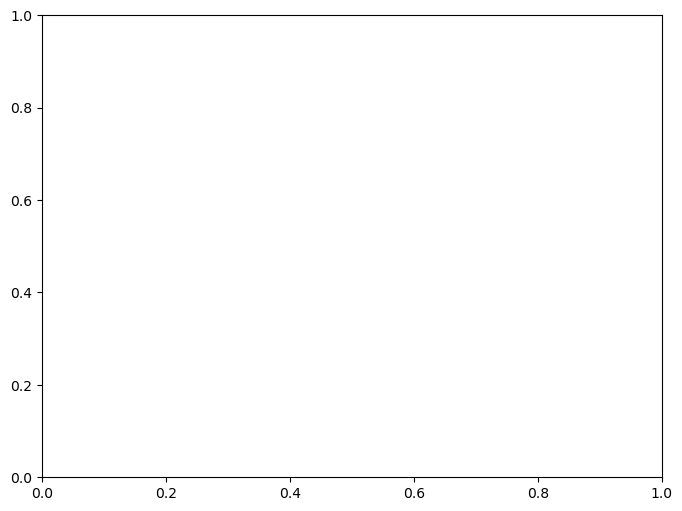

In [3]:
# Save Random Forest confusion matrix for presentation
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure for Random Forest only
fig, ax = plt.subplots(figsize=(8, 6))

# Get confusion matrix
cm = results_week2['RandomForest']['confusion_matrix']
class_labels = ['Inactive\n(0 blocks)', 'Low Activity\n(1-3 blocks)', 'High Activity\n(4+ blocks)']

# Plot heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=class_labels, yticklabels=class_labels,
            cbar_kws={'label': 'Count'}, annot_kws={'size': 14})

# Get metrics
acc = results_week2['RandomForest']['accuracy']
f1_macro = results_week2['RandomForest']['f1_macro']
f1_weighted = results_week2['RandomForest']['f1_weighted']

# Title with metrics
ax.set_title(f'Random Forest - Week 2 Block Prediction\n' + 
             f'Accuracy: {acc:.3f} | Macro F1: {f1_macro:.3f} | Weighted F1: {f1_weighted:.3f}',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Predicted Class', fontsize=12, fontweight='bold')
ax.set_ylabel('True Class', fontsize=12, fontweight='bold')

plt.tight_layout()

# Save to file
output_path = '../rf_confusion_matrix_week2.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Random Forest confusion matrix saved to: {output_path}")
print(f"  Image size: 300 DPI, high quality for presentations")

plt.show()



### Save Trained Models

In [ ]:
# Save all trained models
import joblib

metadata_path = save_models(
    results_week2, 
    scaler=data['scaler'], 
    feature_cols=list(X.columns), 
    week_label="Week 2"
)

# Also save results for import into multi-week comparison notebook
results_path = "../../data/ale_simplicistic_model/relative/model_ready/results_week2.pkl"
joblib.dump(results_week2, results_path)
print(f"\n✓ Week 2 results saved for comparison: {results_path}")


SAVING MODELS - Week 2
✓ LogisticRegression saved: ../data/ale_simplicistic_model/relative/model_ready/logisticregression_week2_20260128_114227.pkl
✓ RandomForest saved: ../data/ale_simplicistic_model/relative/model_ready/randomforest_week2_20260128_114227.pkl
✓ GradientBoosting saved: ../data/ale_simplicistic_model/relative/model_ready/gradientboosting_week2_20260128_114227.pkl
✓ Scaler saved: ../data/ale_simplicistic_model/relative/model_ready/scaler_week2_20260128_114227.pkl
✓ Metadata saved: ../data/ale_simplicistic_model/relative/model_ready/metadata_week2_20260128_114227.pkl

✓ Week 2 results saved for comparison: ../data/ale_simplicistic_model/relative/model_ready/results_week2.pkl
